In [60]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
%load_ext autoreload
%autoreload 2
%matplotlib inline

import portfolio_analytics as erk
import pandas as pd
import numpy as np
from scipy.optimize import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
ind = erk.get_ind_returns()
er = erk.annualize_rets(ind['1996':'2000'], 12)
cov = ind['1996': '2000'].cov()

In [62]:
def msr(riskfree_rate, er, cov):
    """
    Returns the weights of the Maximum Sharpe Ratio portfolio.
    """
    n = er.shape[0]
    init_guess = np.repeat(1/n, n)
    bounds = ((0.0, 1.0),) * n

    weights_sum_to_1 = {
        'type': 'eq',
        'fun': lambda weights: np.sum(weights) - 1
    }

    def neg_sharpe_ratio(weights, riskfree_rate, er, cov):  # ← cov ajouté
        r = erk.portfolio_return(weights, er)
        vol = erk.portfolio_vol(weights, cov)               # ← cov ici
        return -(r - riskfree_rate) / vol

    result = minimize(
        neg_sharpe_ratio,
        init_guess,
        args=(riskfree_rate, er, cov,),  # ← cov déjà présent ici
        method='SLSQP',
        options={'disp': False},
        constraints=(weights_sum_to_1,),
        bounds=bounds
    )
    return result.x

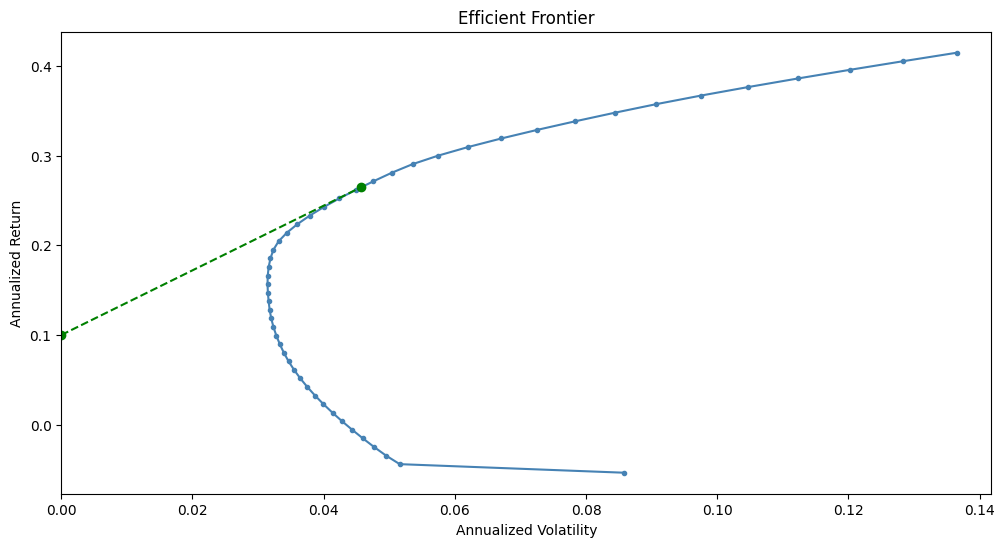

In [63]:
ax = erk.plot_ef(50, er,cov)
ax.set_xlim(left=0) #optionnel
rf = 0.1
w_msr = msr(rf, er, cov)
r_msr = erk.portfolio_return(w_msr,er)
vol_msr = erk.portfolio_vol(w_msr,cov)
cml_x= [0,vol_msr]
cml_y= [rf, r_msr]
ax.plot(cml_x,cml_y, color='green', marker='o', linestyle="dashed")

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Annualized Volatility', ylabel='Annualized Return'>

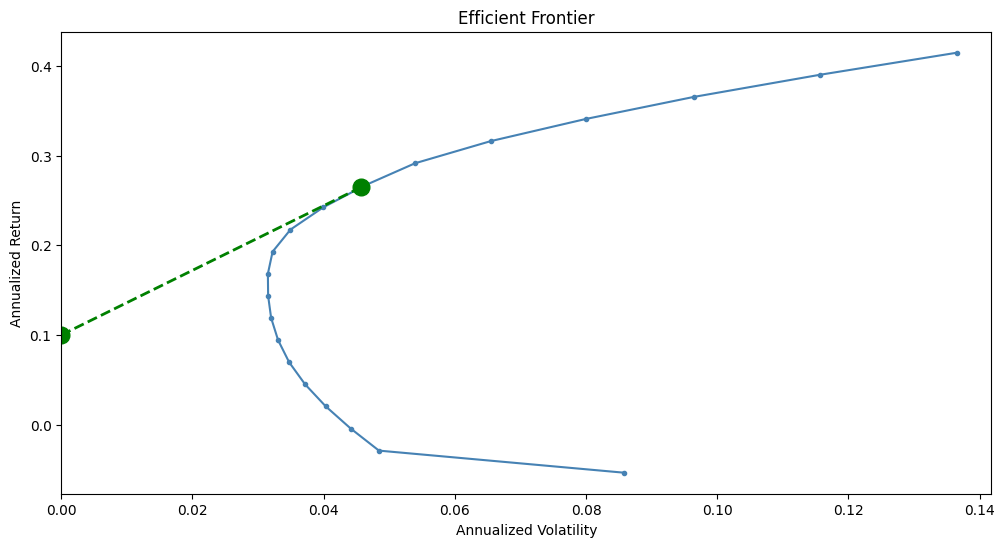

In [64]:
erk.plot_ef(20, er, cov, show_cml=True)

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Annualized Volatility', ylabel='Annualized Return'>

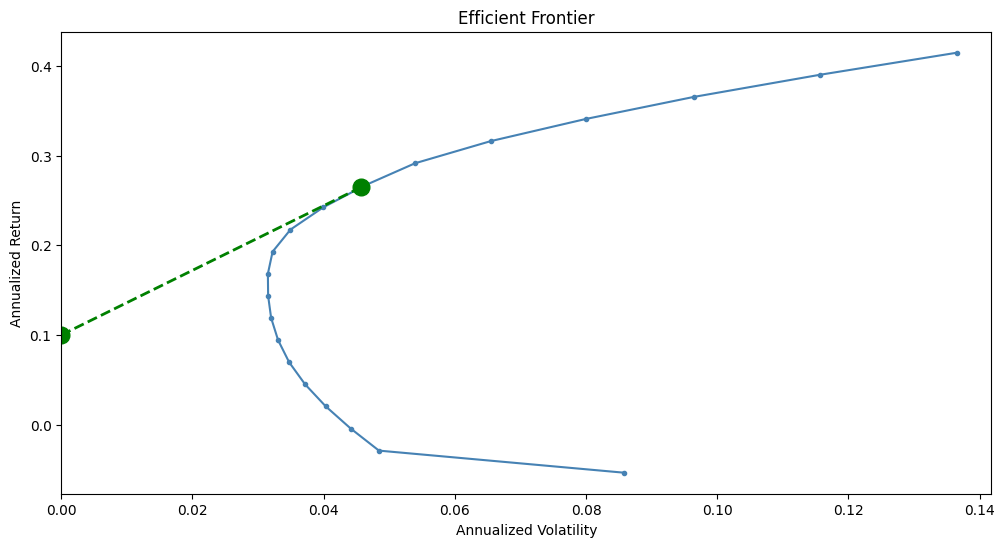

In [66]:
erk.plot_ef(20, er, cov, show_cml=True, riskfree_rate = 0.05)